In [1]:
!pip install -q -U uv
!python -m uv pip install --system autogluon.multimodal

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.9/26.9 MB 62.5 MB/s eta 0:00:00:00:0100:01
Using Python 3.12.13 environment at: /usr
Resolved 169 packages in 3.47s                                       ⠋ Resolving dependencies...                                                     
Prepared 44 packages in 22.69s                                           
Uninstalled 17 packages in 2.21s
Installed 44 packages in 368ms                              
 + aiohttp-cors==0.8.1
 + autogluon-common==1.5.0
 + autogluon-core==1.5.0
 + autogluon-features==1.5.0
 + autogluon-multimodal==1.5.0
 - click==8.3.3
 + click==8.4.2
 + colorful==0.5.8
 - datasets==5.0.0
 + datasets==4.0.0
 - dill==0.4.1
 + dill==0.3.8
 + distlib==0.4.3
 + evaluate==0.4.6
 - huggingface-hub==1.11.0
 + huggingface-hub==0.36.2
 - jsonschema==4.26.0
 + jsonschema==4.23.0
 + lightning==2.5.6
 + model-index==0.1.11
 + nlpaug==1.1.11
 + nvidia-ml-py3==7.352.0
 - nvidia-nvshmem-cu12==3.4.5
 + nvidia-nvshmem-cu12==3.3.20
 + opencensus

In [6]:
#Imports

In [2]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
from autogluon.multimodal import MultiModalPredictor
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='pkg_resources')

/usr/local/lib/python3.12/dist-packages/autogluon/multimodal/data/templates.py:16: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


**#Data Preparation**

In [3]:
df = pd.read_csv(
    '../data/processed/labeled_reviews.csv'  # was a Kaggle-only path; now points at the repo's own processed data
)

df = df.dropna(subset=['content_clean', 'pseudo_label'])
df['pseudo_label'] = df['pseudo_label'].astype(int)

df = df[['content_clean', 'pseudo_label']].rename(columns={'content_clean': 'text', 'pseudo_label': 'label'})

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

print(f"Train: {len(train_df)} | Test: {len(test_df)}")
print("Label balance (train):")
print(train_df['label'].value_counts(normalize=True))

Train: 67203 | Test: 16801
Label balance (train):
label
0    0.871598
1    0.128402
Name: proportion, dtype: float64


**Fine-tune with AutoGluon MultiModal**

Choices:
- `eval_metric='f1'` optimizes for the fake class instead of raw accuracy, which is what you actually care about given the recall problem.
- `presets='best_quality'` tries multiple backbones and ensembles them but can be slow on Kaggle. If you're short on time/GPU quota, switch to `presets='medium_quality'` first to sanity-check the pipeline, then rerun with `best_quality`.
- `time_limit` is in seconds — set it based on your Kaggle session budget so it doesn't get cut off mid-training.

**Compute + storage note:** this trained for the full 3600s (1hr) time limit on a Kaggle GPU. AutoGluon MultiModal checkpoints are large (often several GB), so this folder should be added to `.gitignore` -- do not try to commit it to the repo directly.

In [11]:
predictor = MultiModalPredictor(
    label='label',
    problem_type='binary',
    eval_metric='f1',
    path='../models/autogluon_reviewguardian'  # was a Kaggle-only path; MultiModalPredictor auto-saves
    # to this path during .fit(), so this one-line fix is the entire save fix for this notebook
)

predictor.fit(
    train_data=train_df,
    presets='medium_quality',
    time_limit=3600,
    hyperparameters={"env.num_gpus": 1},
)

=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Sat May 30 15:40:53 UTC 2026
CPU Count:          4
Pytorch Version:    2.9.1+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.28/14.56 GB | GPU 1: 14.56/14.56 GB
Total GPU Memory:   Free: 28.85 GB, Allocated: 0.28 GB, Total: 29.12 GB
GPU Count:          2
Memory Avail:       23.74 GB / 31.35 GB (75.7%)
Disk Space Avail:   19.50 GB / 19.52 GB (99.9%)

AutoMM starts to create your model. ✨✨✨

To track the learning progress, you can open a terminal and launch Tensorboard:
    ```shell
    # Assume you have installed tensorboard
    tensorboard --logdir /kaggle/working/autogluon_reviewguardian
    ```

Seed set to 0


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/54.2M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/54.2M [00:00<?, ?B/s]

...

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Predicting: |          | 0/? [00:00<?, ?it/s]

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Predicting: |          | 0/? [00:00<?, ?it/s]

AutoMM has created your model. 🎉🎉🎉

To load the model, use the code below:
    ```python
    from autogluon.multimodal import MultiModalPredictor
    predictor = MultiModalPredictor.load("/kaggle/working/autogluon_reviewguardian")
    ```

If you are not satisfied with the model, try to increase the training time, 
adjust the hyperparameters (https://auto.gluon.ai/stable/tutorials/multimodal/advanced_topics/customization.html),
or post issues on GitHub (https://github.com/autogluon/autogluon/issues).




**Evaluation Harness**

Same harness as before, so DistilBERT and AutoGluon are scored the exact same way and are directly comparable.

In [14]:
def evaluate_model(y_true, y_pred, y_proba=None, model_name='Model'):
    print(f"=== {model_name} ===")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion matrix:\n", cm)
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc(fpr, tpr):.2f})")
        plt.plot([0,1],[0,1],'k--')
        plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
        plt.legend(); plt.title('ROC Curve')


**Running AutoGluon through the harness**

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Predicting: |          | 0/? [00:00<?, ?it/s]

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Predicting: |          | 0/? [00:00<?, ?it/s]

=== AutoGluon MultiModal ===
              precision    recall  f1-score   support

           0       0.91      0.96      0.93     14644
           1       0.56      0.34      0.43      2157

    accuracy                           0.88     16801
   macro avg       0.73      0.65      0.68     16801
weighted avg       0.86      0.88      0.87     16801

Confusion matrix:
 [[14053   591]
 [ 1414   743]]


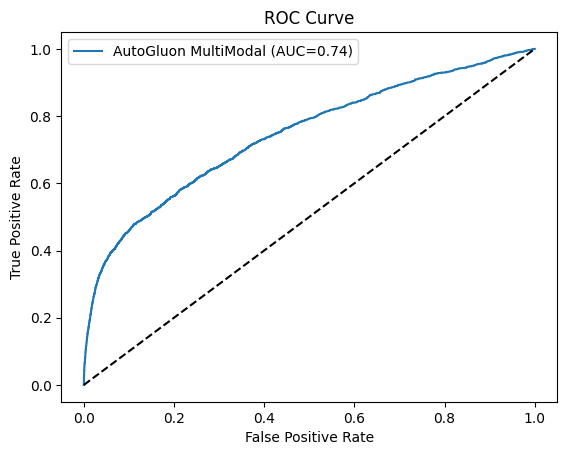

In [15]:
y_pred = predictor.predict(test_df)
y_proba_df = predictor.predict_proba(test_df)   # DataFrame with columns [0, 1]
y_proba = y_proba_df[1].values                  # probability of the "fake" class

evaluate_model(test_df['label'], y_pred, y_proba, 'AutoGluon MultiModal')
plt.show()